INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at: inproc://172.28.0.12/226/1
INFO:distributed.scheduler:  dashboard at:  http://172.28.0.12:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.worker:      Start worker at: inproc://172.28.0.12/226/4
INFO:distributed.worker:         Listening to:          inproc172.28.0.12
INFO:distributed.worker:          Worker name:                          0
INFO:distributed.worker:         dashboard at:          172.28.0.12:37997
INFO:distributed.worker:Waiting to connect to: inproc://172.28.0.12/226/1
INFO:distributed.worker:-------------------------------------------------
INFO:distributed.worker:              Threads:                          2
INFO:distributed.worker:               Memory:                  12.67 GiB
INFO:distrib

Dask dashboard available at: http://172.28.0.12:8787/status
First 5 rows of the dataset:
               State District                Crop  Crop_Year       Season  \
0          Jharkhand   RAMGARH             Potato       2013  Winter        
1  Jammu and Kashmir     REASI  Moong(Green Gram)       2015  Kharif        
2            Haryana   GURGAON       Sweet potato       2009  Whole Year    
3      Uttar Pradesh    JALAUN           Sannhamp       2010  Kharif        
4         Tamil Nadu   MADURAI          Sugarcane       2006  Whole Year    

    Area   Production   Yield  
0  1361.0      7544.0    5.54  
1    13.0         9.0    0.70  
2    39.0       800.0   20.51  
3     9.0         3.0    0.33  
4  6006.0    656204.0  109.26  

Missing Values:
State            0
District         0
Crop             6
Crop_Year        0
Season           0
Area             0
Production    3967
Yield            0
dtype: int64

Descriptive Statistics:
           Crop_Year          Area    Production 

<ipython-input-7-11659ff620b0>:50: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


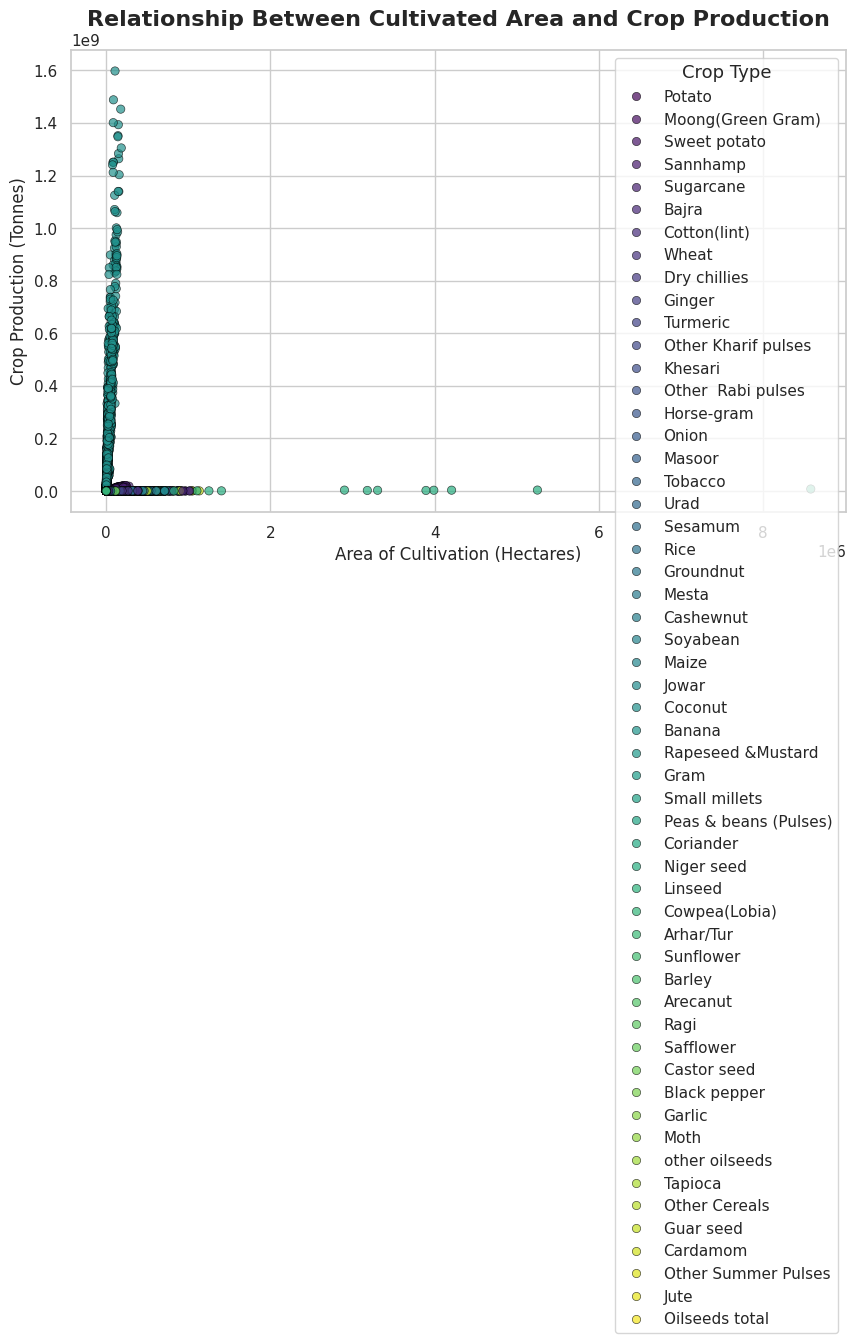

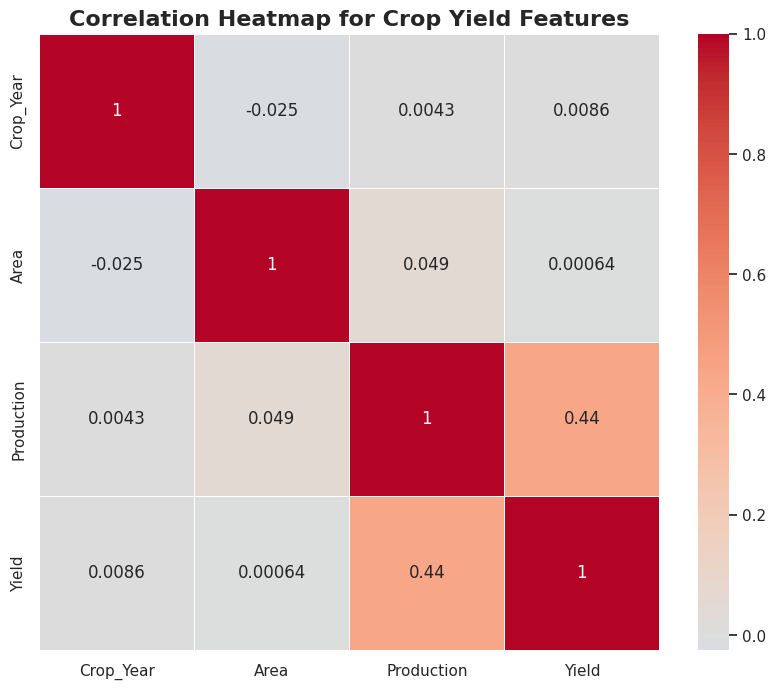

INFO:distributed.scheduler:Remove client Client-1f6b0373-1a85-11f0-80e2-0242ac1c000c
INFO:distributed.core:Received 'close-stream' from inproc://172.28.0.12/226/6; closing.
INFO:distributed.scheduler:Remove client Client-1f6b0373-1a85-11f0-80e2-0242ac1c000c
INFO:distributed.scheduler:Close client connection: Client-1f6b0373-1a85-11f0-80e2-0242ac1c000c
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1744781970.8595333') [0]
INFO:distributed.worker:Stopping worker at inproc://172.28.0.12/226/4. Reason: worker-close
INFO:distributed.worker:Removing Worker plugin shuffle
INFO:distributed.core:Received 'close-stream' from inproc://172.28.0.12/226/5; closing.
INFO:distributed.scheduler:Remove worker addr: inproc://172.28.0.12/226/4 name: 0 (stimulus_id='handle-worker-cleanup-1744781970.8668745')
INFO:distributed.scheduler:Lost all workers
INFO:distributed.core:Connection to inproc://172.28.0.12/226/1 has been closed.
INFO:distributed.scheduler:Closing schedule

In [7]:
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns
from dask.distributed import Client
import pandas as pd

client = Client(processes=False)
print(f"Dask dashboard available at: {client.dashboard_link}")

df = dd.read_csv('crop_yield_train.csv')

print("First 5 rows of the dataset:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum().compute())

df.columns = df.columns.str.strip()

print("\nDescriptive Statistics:")
print(df.describe().compute())

df_pandas = df.compute()

plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_pandas,
    x='Area',
    y='Production',
    hue='Crop',
    palette='viridis',
    alpha=0.7,
    edgecolor='black'
)

plt.title('Relationship Between Cultivated Area and Crop Production', fontsize=16, fontweight='bold')
plt.xlabel('Area of Cultivation (Hectares)', fontsize=12)
plt.ylabel('Crop Production (Tonnes)', fontsize=12)
plt.legend(title='Crop Type', title_fontsize='13', fontsize='11')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,8))
correlation = df_pandas.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap for Crop Yield Features', fontsize=16, fontweight='bold')
plt.show()

client.close()
